# Test Fine-Tuned Florence-2 Model
Mã nguồn này sử dụng model đã được fine-tune (lưu trong thư mục `epoch_3`) để dự đoán kết quả dựa trên các ảnh trong thư mục `test_images/`.

In [ ]:
import os
import torch
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor

# Thiết lập device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Đường dẫn tới model đã fine-tune
model_path = './epoch_3'

print(f"Loading model from {model_path}...")
model = AutoModelForCausalLM.from_pretrained(model_path, trust_remote_code=True).to(device)
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
print("Model loaded successfully!")

Using device: cpu
Loading model from ./epoch_3...


Model loaded successfully!


In [ ]:
def test_model_on_image(image_path, question):
    # Load và xử lý ảnh
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    
    # Tạo prompt. Mô hình fine-tune đang dùng '<vqa>' làm prefix.
    prompt = "<vqa> " + question if "<vqa>" not in question.lower() else question
    
    # Chuẩn bị input cho model
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)
    
    # Generate câu trả lời
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        do_sample=False,
        num_beams=3
    )
    
    # Decode kết quả
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    
    # Post-process để lấy ra kết quả cuối cùng theo format của Florence-2
    try:
        parsed_answer = processor.post_process_generation(generated_text, task="<vqa>", image_size=(image.width, image.height))
    except:
        # Nếu hàm post_process_generation bị lỗi với bản custom model, fallback về kết quả decode thông thường.
        parsed_answer = processor.decode(generated_ids[0], skip_special_tokens=True)
        
    return parsed_answer

Starting inference on test images...

--------------------------------------------------
Processing: images.jpg


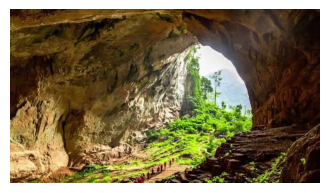

Question: What is the name of the tourist destination shown in this image?
Answer: Phong Nha-Ke Bang National Park is a UNESCO World Heritage site located in Quang Binh province, globally celebrated for harboring some of the oldest and largest karst formations in Asia. The park features an intricate underground river network and spectacular caverns, including Son Doong and Paradise Cave, surrounded by dense tropical rainforest rich in biodiversity.
--------------------------------------------------
Processing: mu-cang-chai-1512708804.png


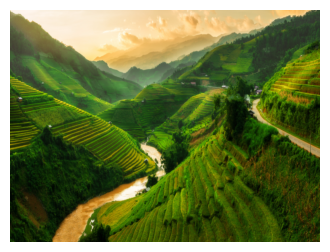

Question: What is the name of the tourist destination shown in this image?
Answer: Phong Nha-Ke Bang National Park is a UNESCO World Heritage site located in Quang Binh province, globally celebrated for harboring some of the oldest and largest karst formations in Asia. The park features an intricate underground river network and spectacular caverns, including Son Doong and Paradise Cave, surrounded by dense tropical rainforest rich in biodiversity.


In [ ]:
import matplotlib.pyplot as plt

test_images_dir = './test_images'
default_question = "What is the name of the tourist destination shown in this image?"

print("Starting inference on test images...\n")

if not os.path.exists(test_images_dir):
    print(f"Thư mục {test_images_dir} không tồn tại.")
else:
    for filename in os.listdir(test_images_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            image_path = os.path.join(test_images_dir, filename)
            print("-"*50)
            print(f"Processing: {filename}")
            
            # Hiển thị ảnh
            img = Image.open(image_path)
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
            
            try:
                answer = test_model_on_image(image_path, default_question)
                print(f"Question: {default_question}")
                if isinstance(answer, dict) and '<vqa>' in answer:
                    print(f"Answer: {answer['<vqa>']}")
                else:
                    print(f"Answer: {answer}")
            except Exception as e:
                print(f"Lỗi trong quá trình xử lý {filename}: {e}")